# HAH913E – Physical Activity Assignment 00

**Team members:** Thomas Vigneau-Sugar

**GitHub repository:** [Git-Series-00](https://github.com/tom22121/Git-Series-00)

## Objective

The objective of this assignment is to calculate ENMO from tri-axial accelerometer data and to investigate the effect of different epoch durations on integrated ENMO.

In [68]:
import numpy as np
import matplotlib.pyplot as plt

## Load the accelerometer data

The file contains time and acceleration values for the x, y and z axes.
The first two lines are skipped because they contain information about the data and the column names.

In [69]:
data = np.loadtxt("0_z.csv", delimiter=",", skiprows=2)

data[:5]

array([[ 0.    , -0.0938, -0.0156,  0.9531],
       [ 0.02  , -0.0938, -0.0156,  0.9531],
       [ 0.04  , -0.0938, -0.0156,  0.9531],
       [ 0.06  , -0.0938, -0.0156,  0.9531],
       [ 0.08  , -0.0938, -0.0156,  0.9531]])

In [70]:
print("Number of samples:", len(data))
print("Number of columns:", data.shape[1])
print("Start time:", data[0, 0], "s")
print("End time:", data[-1, 0], "s")

Number of samples: 21000
Number of columns: 4
Start time: 0.0 s
End time: 419.98 s


In [71]:
dt = data[1, 0] - data[0, 0]
fs = 1 / dt

print("Sampling interval:", dt, "s")
print("Sampling frequency:", fs, "Hz")

Sampling interval: 0.02 s
Sampling frequency: 50.0 Hz


## Sampling frequency

The time difference between two consecutive samples is 0.02 s, corresponding to a sampling frequency of 50 Hz.

Knowing the sampling frequency is necessary to convert the epoch duration from seconds to number of samples.

## ENMO calculation

ENMO is calculated from the acceleration magnitude of the three axes.

$$
ENMO = \sqrt{x^2 + y^2 + z^2} - 1
$$

The subtraction of 1 g removes the contribution of gravity from the acceleration magnitude.

In [72]:
def calculate_enmo(x, y, z):
    magnitude = np.sqrt(x**2 + y**2 + z**2)
    enmo = magnitude - 1
    return enmo


x = data[:, 1]
y = data[:, 2]
z = data[:, 3]

enmo = calculate_enmo(x, y, z)

enmo[:5]

array([-0.04216838, -0.04216838, -0.04216838, -0.04216838, -0.04216838])

In [73]:
print("Maximum ENMO:", np.max(enmo))
print("Mean ENMO:", np.mean(enmo))
print("Non-zero samples:", np.count_nonzero(enmo))

Maximum ENMO: 12.784615518758585
Mean ENMO: 0.016746399177041165
Non-zero samples: 21000


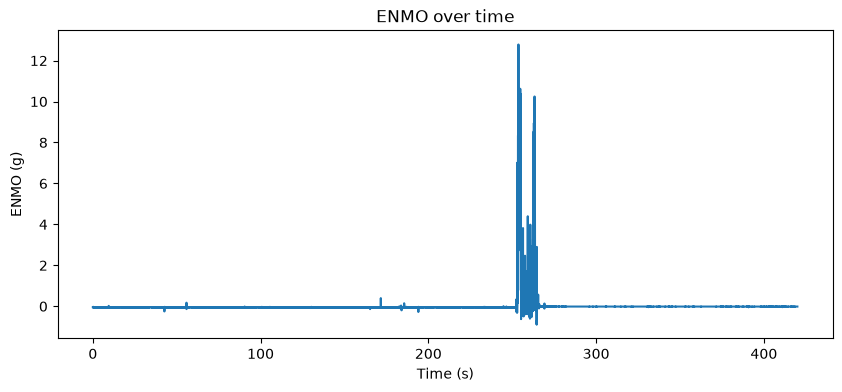

In [74]:
time = data[:, 0]

plt.figure(figsize=(10, 4))
plt.plot(time, enmo)
plt.xlabel("Time (s)")
plt.ylabel("ENMO (g)")
plt.title("ENMO over time")
plt.show()

## ENMO integration over epochs

To analyse physical activity over different time intervals, the ENMO signal is divided into epochs of fixed duration.

The number of samples in each epoch is determined using the sampling frequency. ENMO is then integrated separately within each epoch.

Epoch durations of 10 s, 30 s and 60 s are compared as required in the assignment.

In [75]:
def integrate_enmo(enmo, epoch_seconds, fs):
    samples_per_epoch = int(epoch_seconds * fs)
    n_epochs = len(enmo) // samples_per_epoch

    integrated = []

    for i in range(n_epochs):
        start = i * samples_per_epoch
        end = start + samples_per_epoch
        integrated.append(np.sum(enmo[start:end]) * 1000 / (fs * 60))

    return np.array(integrated)

### 10-second epochs

The ENMO signal is first integrated using 10-second epochs. At a sampling frequency of 50 Hz, each 10-second epoch contains 500 samples.

In [76]:
epoch_seconds = 10

integrated_10 = integrate_enmo(enmo, epoch_seconds, fs)

print("Number of 10 s epochs:", len(integrated_10))
print(integrated_10[:5])

Number of 10 s epochs: 42
[-7.55969727 -7.52010159 -7.54019449 -7.51932679 -7.6781184 ]


In [77]:
epoch_seconds = 10

time_10 = np.arange(len(integrated_10)) * epoch_seconds

print(time_10)

[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170
 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350
 360 370 380 390 400 410]


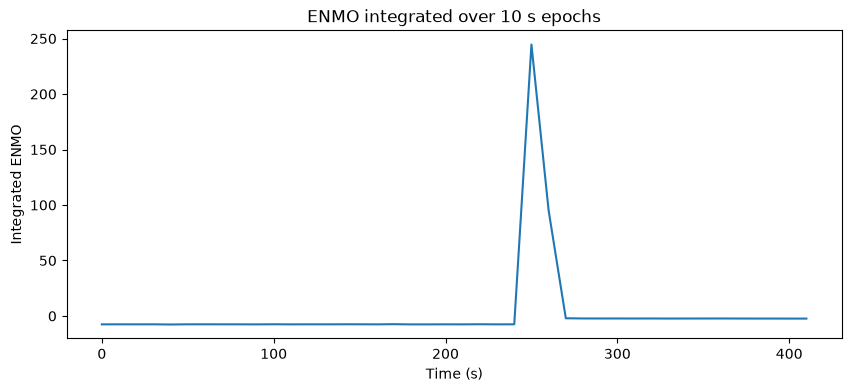

In [78]:
plt.figure(figsize=(10, 4))

plt.plot(time_10, integrated_10)

plt.xlabel("Time (s)")
plt.ylabel("Integrated ENMO")
plt.title("ENMO integrated over 10 s epochs")

plt.show()

## Comparison of different epoch durations

To investigate the effect of epoch duration on integrated ENMO, the signal is integrated using several epoch lengths. Shorter epochs preserve more temporal detail, whereas longer epochs provide a more aggregated representation of physical activity.

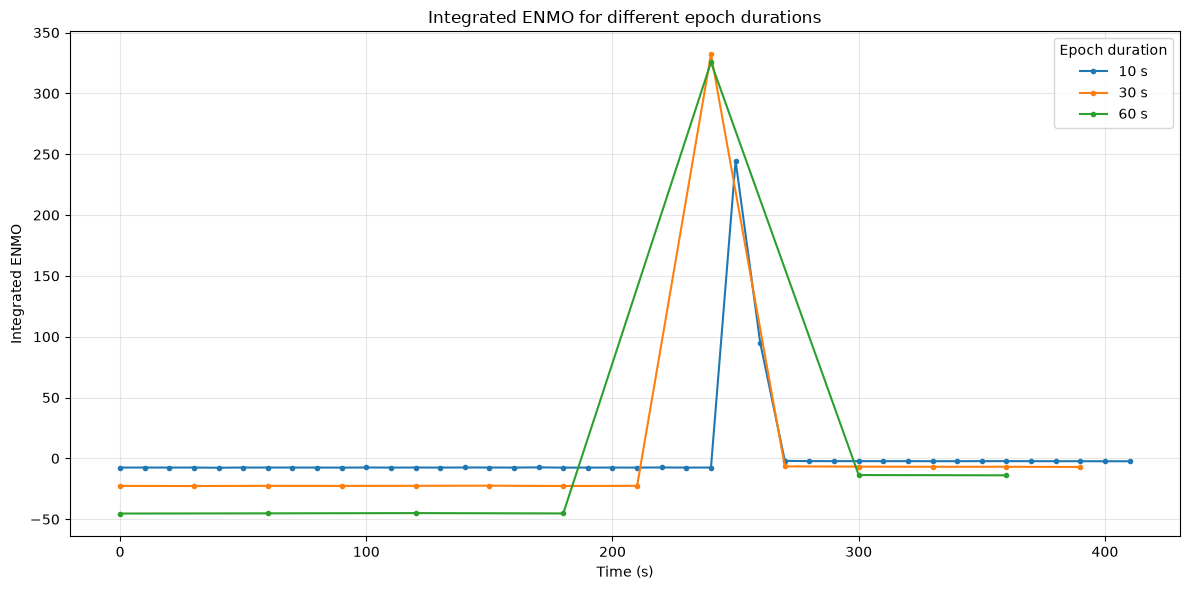

In [79]:
epoch_durations = [10, 30, 60]

plt.figure(figsize=(12, 6))

for epoch_seconds in epoch_durations:
    integrated = integrate_enmo(enmo, epoch_seconds, fs)
    epoch_time = np.arange(len(integrated)) * epoch_seconds

    plt.plot(
        epoch_time,
        integrated,
        marker="o",
        markersize=3,
        label=f"{epoch_seconds} s"
    )

plt.xlabel("Time (s)")
plt.ylabel("Integrated ENMO")
plt.title("Integrated ENMO for different epoch durations")
plt.legend(title="Epoch duration")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Interpretation

The epoch duration affects the temporal resolution of the integrated ENMO signal.

With a 10 s epoch, changes in physical activity are represented with greater temporal detail. As the epoch duration increases to 30 s and 60 s, the signal becomes more aggregated and short variations in activity are less visible.

The main period of increased physical activity is visible with all three epoch durations, although its representation changes depending on the selected epoch length.